# Computational Features Analysis: Box Plots & Lasso Regression

## Focus Areas

This notebook analyzes **ONLY computational features** (no sequence analysis):

1. **Extensive Box Plot Analysis**
   - Binders vs Non-binders
   - By target
   - By binding strength categories
   - Statistical significance testing

2. **Lasso Regression on All Computational Features**
   - Feature selection
   - Coefficient interpretation
   - Model performance

3. **Key Features of Interest**
   - ESMFold pLDDT (confidence)
   - ProteinMPNN scores (designability)
   - Sequence identity metrics
   - Physicochemical properties
   - Any ipSAE-like features if available

**Principle**: Computational features ONLY → predict experimental outcomes

## 1. Setup

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from src.utils.data_loader import ProteinDataLoader

# Set plotting style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Setup complete")

✓ Setup complete


## 2. Load Computational Features and Experimental Labels

In [2]:
# Load data
data_path = '../proteinbase_all_data_28_01_2026.csv'
loader = ProteinDataLoader(data_path)
loader.load_data()

# Get COMPUTATIONAL features only
computational_df = loader.get_computational_features()
experimental_df = loader.get_experimental_features()

print(f"\nComputational features: {computational_df.shape}")
print(f"Experimental features: {experimental_df.shape}")

Loading data from ../proteinbase_all_data_28_01_2026.csv...
Loaded 5253 protein designs
Extracting COMPUTATIONAL features only (preventing data leakage)...
Extracted 84 computational features
Total columns (including metadata): 98
Extracting EXPERIMENTAL features only...
Extracted 114 experimental feature columns

Computational features: (5253, 98)
Experimental features: (5253, 114)


In [3]:
# Display all available computational features
comp_cols = [col for col in computational_df.columns if 'computational' in col.lower()]

print(f"\n{'='*80}")
print(f"ALL COMPUTATIONAL FEATURES ({len(comp_cols)} total)")
print(f"{'='*80}")

# Group by metric type
feature_groups = {}
for col in comp_cols:
    # Extract metric name (before first underscore or 'computational')
    parts = col.split('_')
    metric_base = parts[0]
    
    if metric_base not in feature_groups:
        feature_groups[metric_base] = []
    feature_groups[metric_base].append(col)

for metric, features in sorted(feature_groups.items()):
    print(f"\n{metric.upper()}:")
    for f in features[:5]:  # Show first 5
        print(f"  - {f}")
    if len(features) > 5:
        print(f"  ... and {len(features)-5} more")


ALL COMPUTATIONAL FEATURES (93 total)

ALIGNED:
  - aligned_length_computational

ALIGNED-LENGTHAFDB50:
  - aligned-lengthafdb50_computational

ALIGNED-LENGTHCATH50:
  - aligned-lengthcath50_computational

ALIGNED-LENGTHPDB100:
  - aligned-lengthpdb100_computational

BOLTZ2:
  - boltz2_pdockq2_nipah-glycoprotein-g_computational
  - boltz2_complex_pde_nipah-glycoprotein-g_computational
  - boltz2_ptm_nipah-glycoprotein-g_computational
  - boltz2_plddt_nipah-glycoprotein-g_computational
  - boltz2_complex_iplddt_nipah-glycoprotein-g_computational
  ... and 35 more

CATH:
  - cath_detail_computational

CLASSIFICATION:
  - classification_computational

DESIGN:
  - design_class_computational

DOMAINMATCH:
  - domainmatch_seqidentity_afdb50_computational
  - domainmatch_evalue_afdb50_computational
  - domainmatch_tm_score_afdb50_computational
  - domainmatch_rmsd_afdb50_computational
  - domainmatch_aligned_length_afdb50_computational
  ... and 11 more

ESMFOLD:
  - esmfold_plddt_computatio

## 3. Extract Target-Specific Binding Data

In [4]:
# Extract binding data per target
import json

def extract_binding_by_target(evaluations_str):
    """Extract experimental binding data organized by target."""
    try:
        evals = json.loads(evaluations_str) if isinstance(evaluations_str, str) else []
    except:
        return {}
    
    targets = {}
    
    for item in evals:
        if item.get('type') != 'experimental':
            continue
        
        target = item.get('target')
        if not target or target == 'unknown':
            continue
        
        metric = item.get('metric')
        value = item.get('value')
        
        if target not in targets:
            targets[target] = {'binding': None, 'kd': None, 'pkd': None}
        
        if metric == 'binding' and isinstance(value, bool):
            targets[target]['binding'] = int(value)
        elif metric == 'kd' and isinstance(value, (int, float)) and value > 0:
            targets[target]['kd'] = value
            targets[target]['pkd'] = -np.log10(value)
    
    return targets

raw_data = loader.raw_data.copy()
raw_data['target_binding'] = raw_data['evaluations'].apply(extract_binding_by_target)

print("✓ Extracted target-specific binding data")

✓ Extracted target-specific binding data


In [5]:
# Create long-format dataset
records = []

for idx, row in raw_data.iterrows():
    for target, binding_data in row['target_binding'].items():
        record = {
            'sample_id': idx,
            'protein_id': row.get('id', idx),
            'target': target,
            **binding_data
        }
        records.append(record)

binding_df = pd.DataFrame(records)

# Merge with computational features
comp_numeric = computational_df.select_dtypes(include=[np.number])

analysis_df = binding_df.merge(
    comp_numeric,
    left_on='sample_id',
    right_index=True,
    how='left'
)

print(f"\nAnalysis dataset:")
print(f"  Shape: {analysis_df.shape}")
print(f"  Protein-target pairs: {len(analysis_df)}")
print(f"  With binding data: {analysis_df['binding'].notna().sum()}")
print(f"  With KD data: {analysis_df['kd'].notna().sum()}")
print(f"  Unique targets: {analysis_df['target'].nunique()}")


Analysis dataset:
  Shape: (2640, 90)
  Protein-target pairs: 2640
  With binding data: 2630
  With KD data: 435
  Unique targets: 24


In [6]:
# Add binding strength categories
def categorize_binding_strength(pkd):
    """Categorize binding by pKD (stronger = higher pKD = lower KD)."""
    if pd.isna(pkd):
        return 'Unknown'
    elif pkd >= 9:  # KD <= 1 nM
        return 'Very Strong'
    elif pkd >= 8:  # KD <= 10 nM
        return 'Strong'
    elif pkd >= 7:  # KD <= 100 nM
        return 'Moderate'
    elif pkd >= 6:  # KD <= 1 µM
        return 'Weak'
    else:  # KD > 1 µM
        return 'Very Weak'

analysis_df['binding_category'] = analysis_df['pkd'].apply(categorize_binding_strength)

print("\nBinding strength categories:")
print(analysis_df['binding_category'].value_counts().sort_index())


Binding strength categories:
binding_category
Moderate        190
Strong           55
Unknown        2205
Very Strong      10
Very Weak        46
Weak            134
Name: count, dtype: int64


## 4. Identify Key Computational Features for Analysis

In [7]:
# Get computational features with good data availability
comp_features = [col for col in comp_numeric.columns if col in analysis_df.columns]

# Calculate completeness
feature_completeness = pd.DataFrame({
    'feature': comp_features,
    'n_available': [analysis_df[col].notna().sum() for col in comp_features],
    'pct_available': [analysis_df[col].notna().sum() / len(analysis_df) * 100 for col in comp_features]
}).sort_values('pct_available', ascending=False)

# Filter to features with at least 10% availability
usable_features = feature_completeness[feature_completeness['pct_available'] >= 10]['feature'].tolist()

print(f"\nFeature availability:")
print(f"  Total computational features: {len(comp_features)}")
print(f"  Features with ≥10% data: {len(usable_features)}")
print(f"\nTop 20 most complete features:")
print(feature_completeness.head(20).to_string(index=False))


Feature availability:
  Total computational features: 84
  Features with ≥10% data: 40

Top 20 most complete features:
                                   feature  n_available  pct_available
                           sequence_length         2640     100.000000
redesigned_proteinmpnn_score_computational         2632      99.696970
            molecular_weight_computational         2632      99.696970
    proteinmpnn_seq_recovery_computational         2632      99.696970
           proteinmpnn_score_computational         2632      99.696970
           isoelectric_point_computational         2632      99.696970
               esmfold_plddt_computational         2632      99.696970
              ted_confidence_computational         2537      96.098485
                  rmsdcath50_computational         1656      62.727273
           seqidentitycath50_computational         1656      62.727273
        aligned-lengthcath50_computational         1656      62.727273
                evaluecath50

In [8]:
# Identify key feature types
key_features = {
    'pLDDT': [f for f in usable_features if 'plddt' in f.lower()],
    'ProteinMPNN': [f for f in usable_features if 'proteinmpnn' in f.lower()],
    'SeqIdentity': [f for f in usable_features if 'seqidentity' in f.lower()],
    'Isoelectric': [f for f in usable_features if 'isoelectric' in f.lower()],
    'MolWeight': [f for f in usable_features if 'molecular' in f.lower() or 'weight' in f.lower()],
    'Confidence': [f for f in usable_features if 'confidence' in f.lower()],
    'ipSAE-like': [f for f in usable_features if 'ipsae' in f.lower() or 'sae' in f.lower()],
}

print("\nKey feature groups:")
for category, features in key_features.items():
    if features:
        print(f"\n{category}: {len(features)} features")
        for f in features[:3]:
            print(f"  - {f}")
        if len(features) > 3:
            print(f"  ... and {len(features)-3} more")


Key feature groups:

pLDDT: 4 features
  - esmfold_plddt_computational
  - boltz2_complex_iplddt_nipah-glycoprotein-g_computational
  - boltz2_complex_plddt_nipah-glycoprotein-g_computational
  ... and 1 more

ProteinMPNN: 3 features
  - redesigned_proteinmpnn_score_computational
  - proteinmpnn_seq_recovery_computational
  - proteinmpnn_score_computational

SeqIdentity: 4 features
  - seqidentitycath50_computational
  - seqidentityafdb50_computational
  - seqidentitypdb100_computational
  ... and 1 more

Isoelectric: 1 features
  - isoelectric_point_computational

MolWeight: 1 features
  - molecular_weight_computational

Confidence: 1 features
  - ted_confidence_computational

ipSAE-like: 2 features
  - boltz2_min_ipsae_nipah-glycoprotein-g_computational
  - boltz2_ipsae_nipah-glycoprotein-g_computational


## 5. Box Plot Analysis: Binders vs Non-Binders

Compare all computational features between binders and non-binders

In [9]:
# Filter to samples with binding data
binding_data = analysis_df[analysis_df['binding'].notna()].copy()
binding_data['binding_label'] = binding_data['binding'].map({0: 'Non-binder', 1: 'Binder'})

print(f"Samples with binding data: {len(binding_data)}")
print(f"  Binders: {(binding_data['binding']==1).sum()}")
print(f"  Non-binders: {(binding_data['binding']==0).sum()}")

Samples with binding data: 2630
  Binders: 470
  Non-binders: 2160


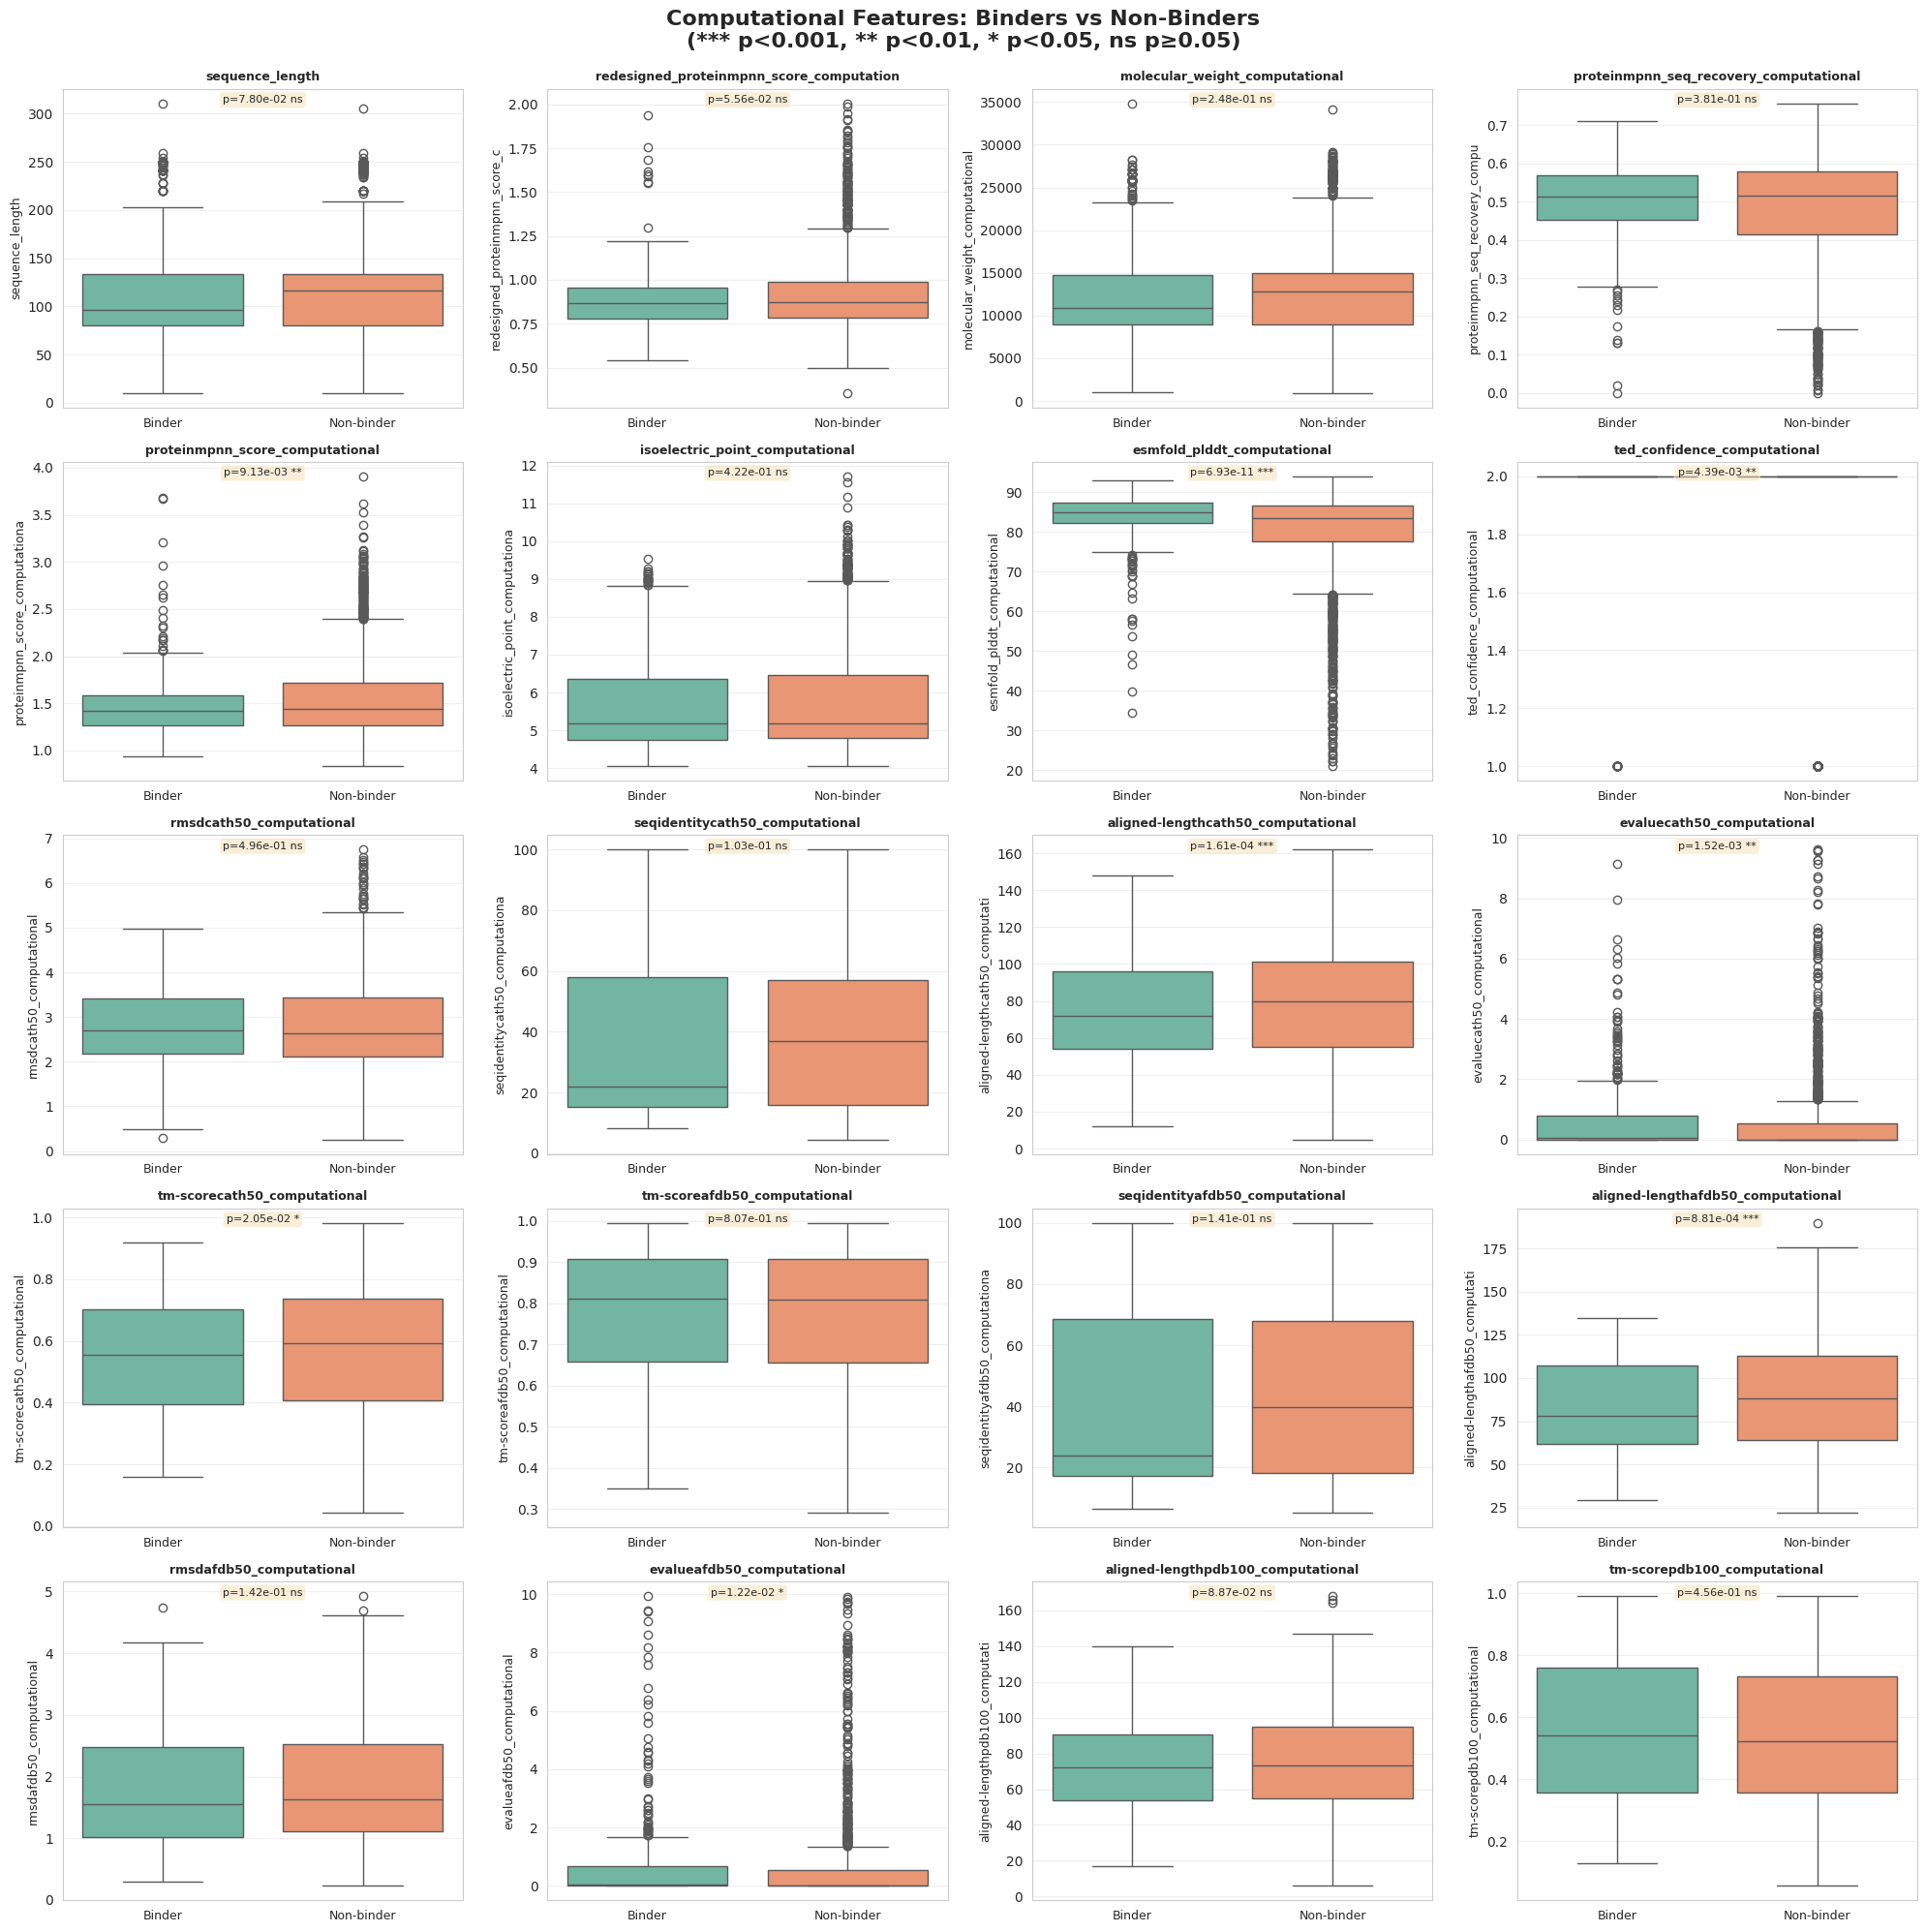

✓ Generated binder vs non-binder box plots


In [10]:
# Create comprehensive box plots
# Select top features for visualization
features_to_plot = usable_features[:min(20, len(usable_features))]

n_features = len(features_to_plot)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    
    # Prepare data
    plot_data = binding_data[[feature, 'binding_label']].dropna()
    
    if len(plot_data) < 10:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(feature[:40], fontsize=9)
        continue
    
    # Box plot
    sns.boxplot(data=plot_data, x='binding_label', y=feature, ax=ax, palette='Set2')
    
    # Statistical test (Mann-Whitney U)
    binders = plot_data[plot_data['binding_label'] == 'Binder'][feature]
    non_binders = plot_data[plot_data['binding_label'] == 'Non-binder'][feature]
    
    if len(binders) > 0 and len(non_binders) > 0:
        statistic, p_value = stats.mannwhitneyu(binders, non_binders, alternative='two-sided')
        
        # Annotate with significance
        sig_label = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns'))
        ax.text(0.5, 0.98, f'p={p_value:.2e} {sig_label}',
               transform=ax.transAxes, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=8)
    
    ax.set_xlabel('', fontsize=10)
    ax.set_ylabel(feature[:30], fontsize=9)
    ax.set_title(feature[:40], fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)
    ax.grid(alpha=0.3, axis='y')

# Remove extra subplots
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Computational Features: Binders vs Non-Binders\n(*** p<0.001, ** p<0.01, * p<0.05, ns p≥0.05)',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/boxplots_binders_vs_nonbinders.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Generated binder vs non-binder box plots")

## 6. Box Plots by Target

In [11]:
# Select a key feature to compare across targets
# Use the most complete feature
key_feature = feature_completeness.iloc[0]['feature']

print(f"Comparing across targets using: {key_feature}")

# Get targets with sufficient data
target_counts = analysis_df.groupby('target')[key_feature].count()
good_targets = target_counts[target_counts >= 10].index.tolist()

print(f"Targets with ≥10 samples: {len(good_targets)}")

Comparing across targets using: sequence_length
Targets with ≥10 samples: 24


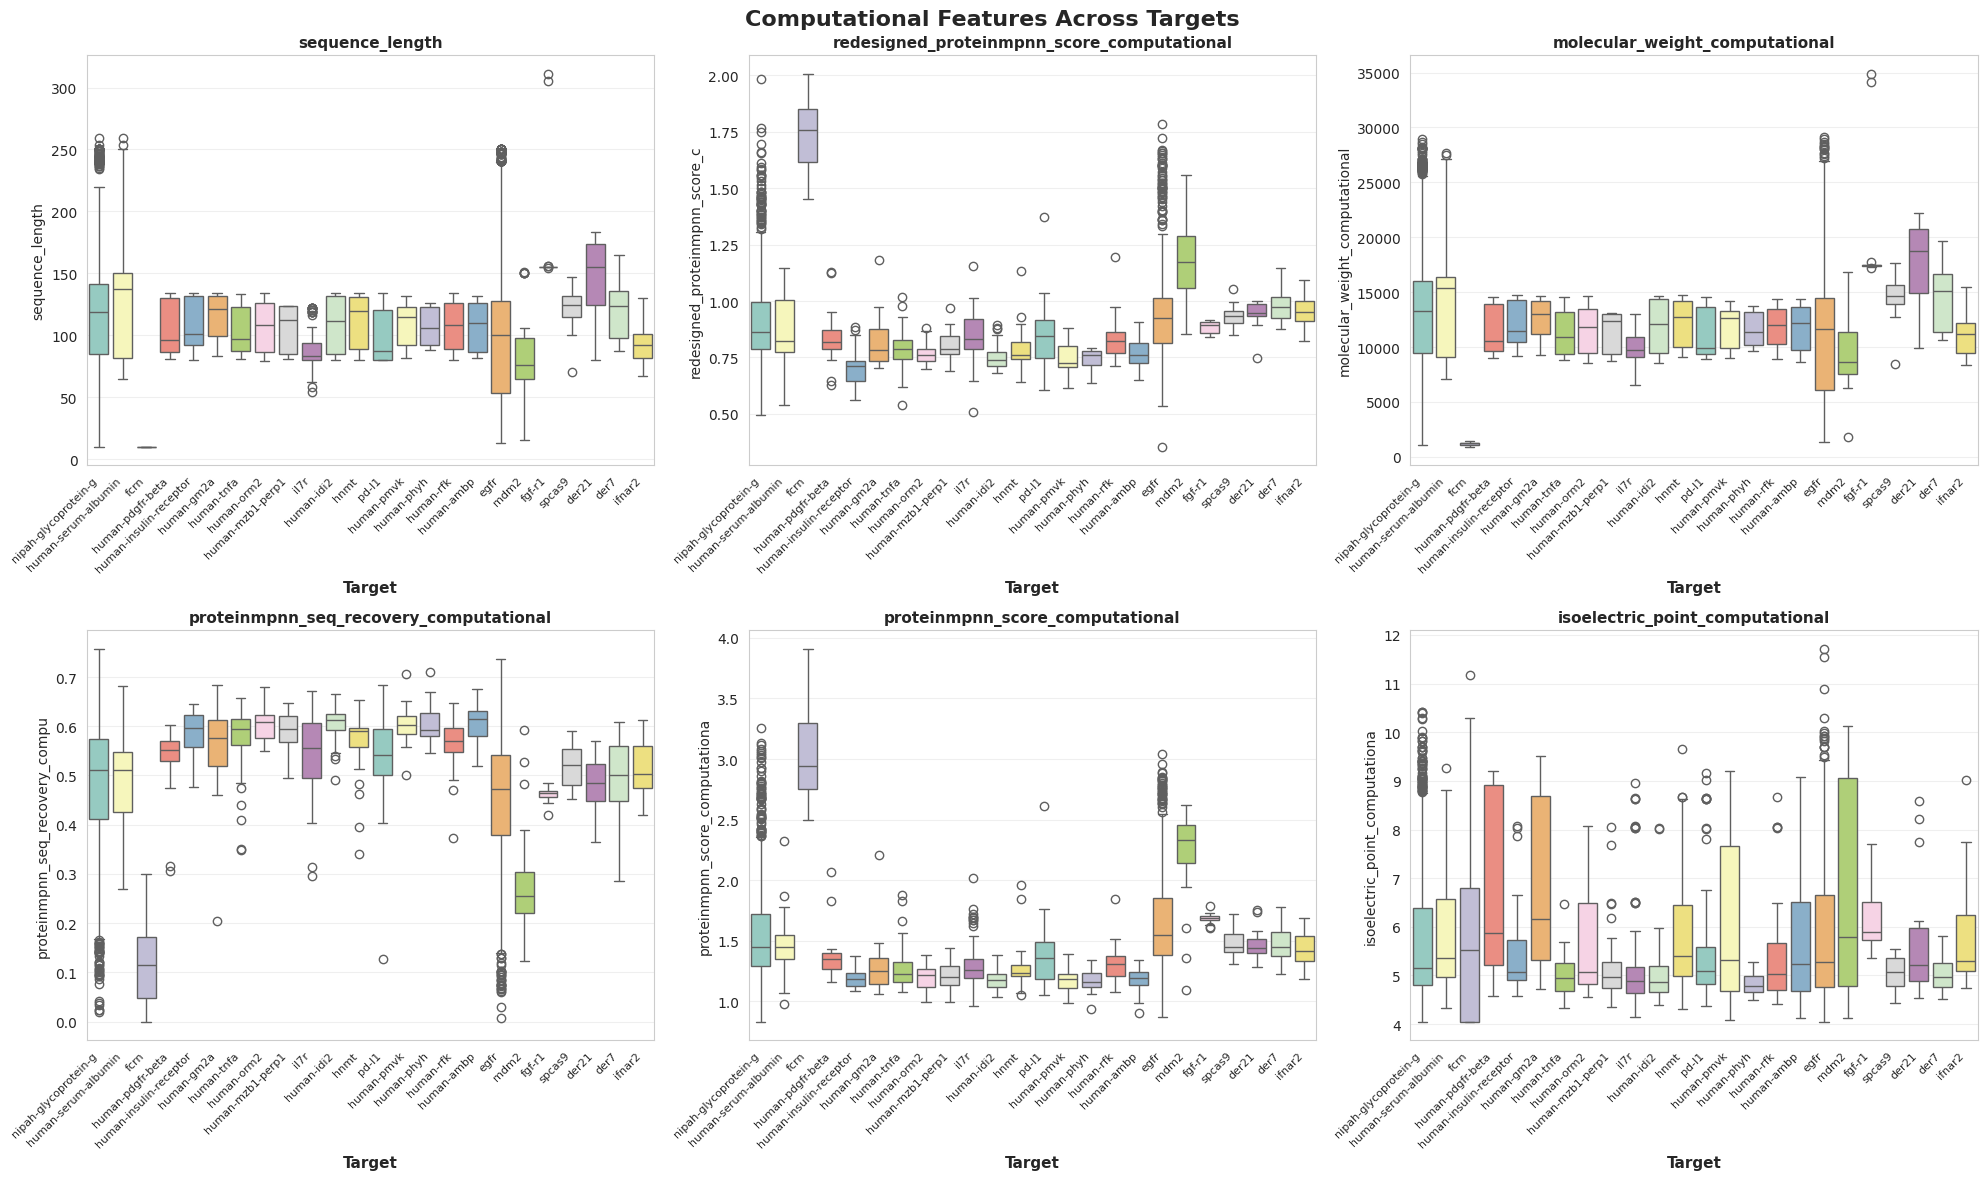

✓ Generated per-target box plots


In [12]:
# Box plots for top feature across targets
if len(good_targets) > 0:
    target_data = analysis_df[analysis_df['target'].isin(good_targets)].copy()
    
    # Plot multiple features across targets
    top_features_for_targets = usable_features[:min(6, len(usable_features))]
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, feature in enumerate(top_features_for_targets):
        if idx >= len(axes):
            break
        
        ax = axes[idx]
        plot_data = target_data[['target', feature]].dropna()
        
        if len(plot_data) < 10:
            continue
        
        # Box plot by target
        sns.boxplot(data=plot_data, x='target', y=feature, ax=ax, palette='Set3')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_xlabel('Target', fontsize=11, fontweight='bold')
        ax.set_ylabel(feature[:30], fontsize=10)
        ax.set_title(feature[:50], fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3, axis='y')
    
    plt.suptitle('Computational Features Across Targets', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/boxplots_by_target.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Generated per-target box plots")

## 7. Box Plots by Binding Strength Category

In [13]:
# Filter to samples with KD data
strength_data = analysis_df[analysis_df['binding_category'] != 'Unknown'].copy()

print(f"\nSamples with binding strength data: {len(strength_data)}")
print(strength_data['binding_category'].value_counts())


Samples with binding strength data: 435
binding_category
Moderate       190
Weak           134
Strong          55
Very Weak       46
Very Strong     10
Name: count, dtype: int64


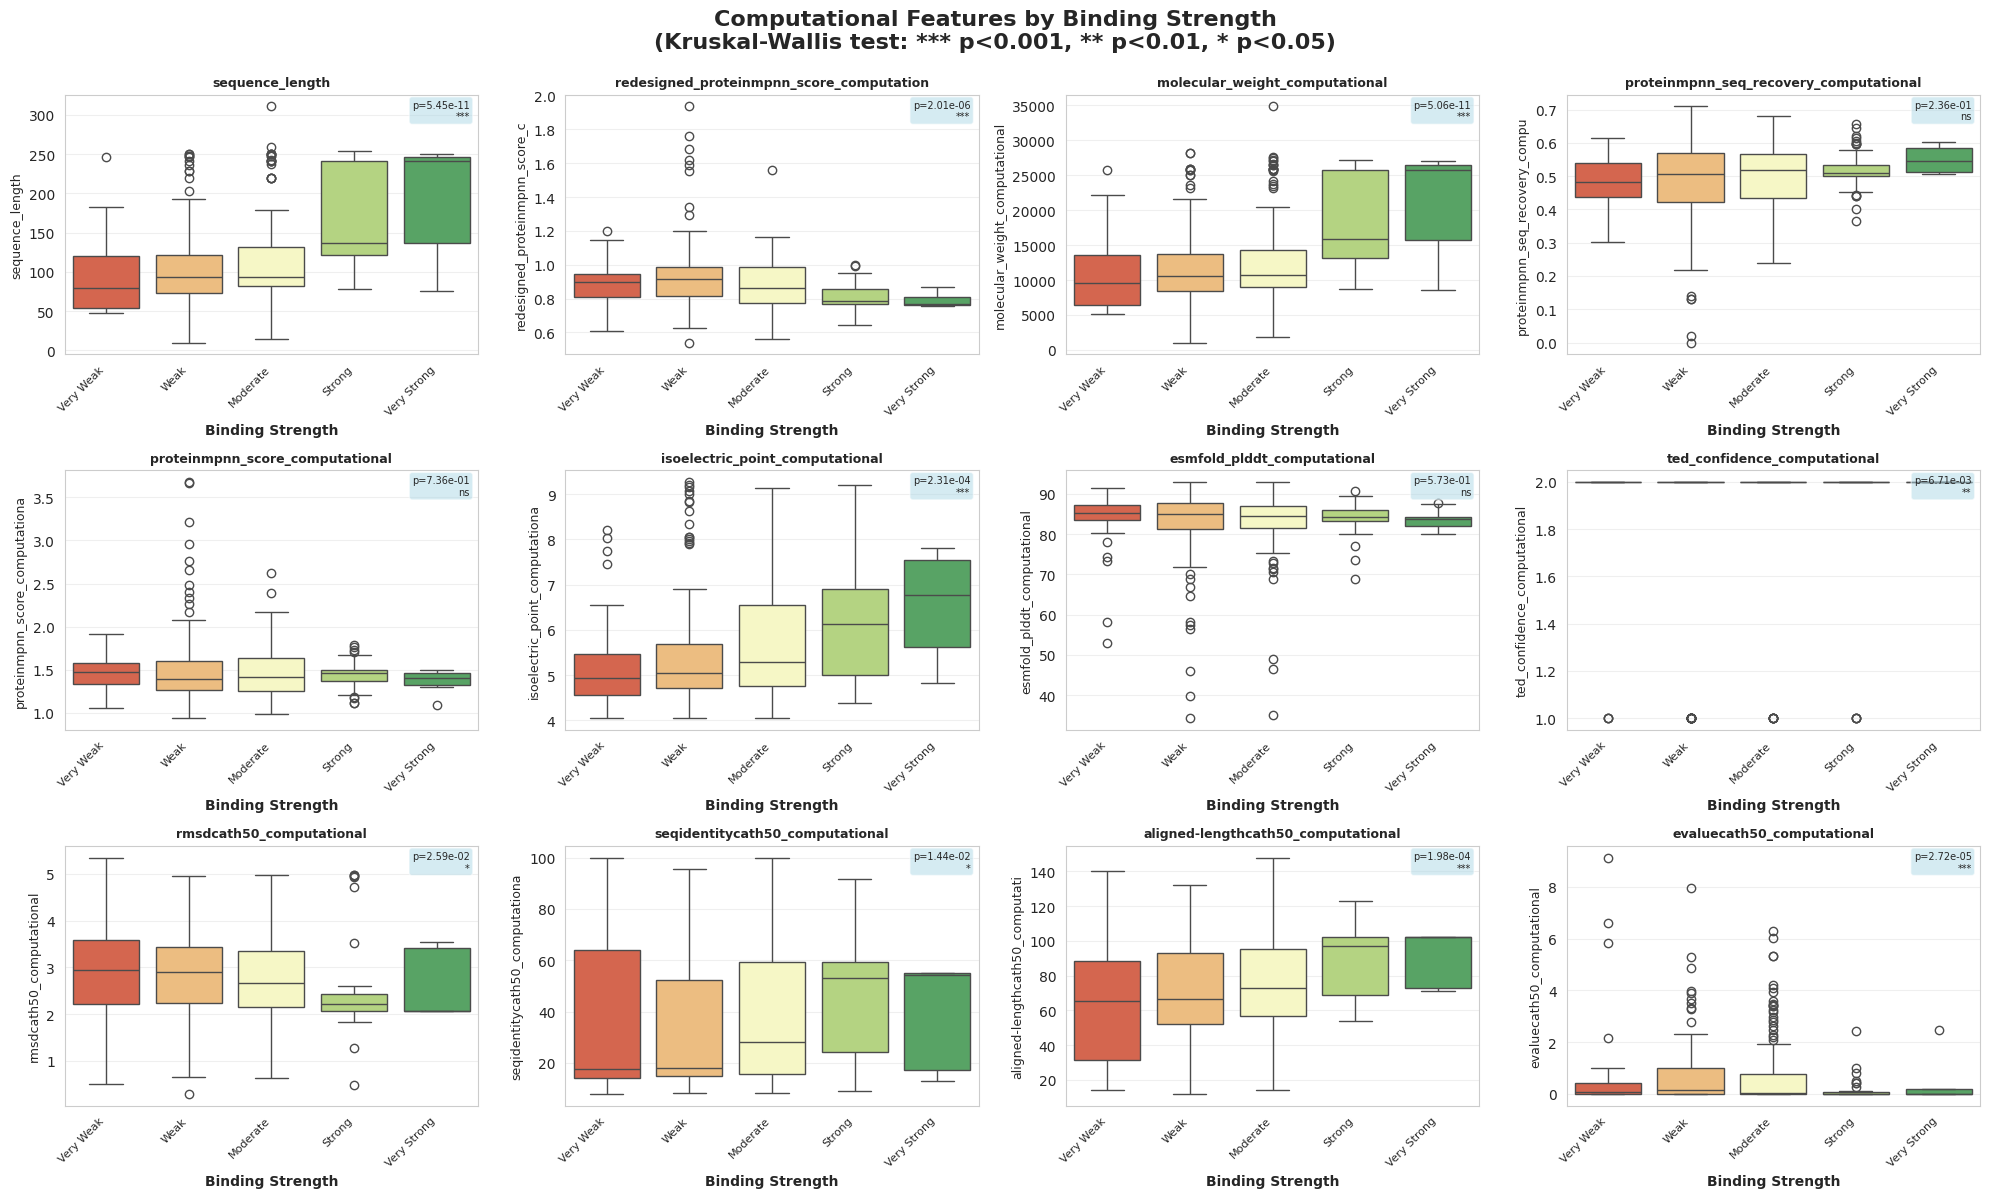

✓ Generated binding strength box plots


In [14]:
# Box plots by binding strength
if len(strength_data) > 20:
    # Select features for strength analysis
    features_for_strength = usable_features[:min(12, len(usable_features))]
    
    n_features = len(features_for_strength)
    n_cols = 4
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
    axes = axes.flatten() if n_features > 1 else [axes]
    
    # Define order for categories
    category_order = ['Very Weak', 'Weak', 'Moderate', 'Strong', 'Very Strong']
    
    for idx, feature in enumerate(features_for_strength):
        ax = axes[idx]
        
        plot_data = strength_data[['binding_category', feature]].dropna()
        
        if len(plot_data) < 10:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Get categories present in data
        present_categories = [cat for cat in category_order if cat in plot_data['binding_category'].unique()]
        
        # Box plot
        sns.boxplot(data=plot_data, x='binding_category', y=feature, 
                   order=present_categories, ax=ax, palette='RdYlGn')
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_xlabel('Binding Strength', fontsize=10, fontweight='bold')
        ax.set_ylabel(feature[:30], fontsize=9)
        ax.set_title(feature[:40], fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3, axis='y')
        
        # Kruskal-Wallis test (non-parametric ANOVA)
        groups = [plot_data[plot_data['binding_category'] == cat][feature].dropna() 
                 for cat in present_categories]
        groups = [g for g in groups if len(g) > 0]
        
        if len(groups) >= 2:
            h_stat, p_value = stats.kruskal(*groups)
            sig_label = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns'))
            ax.text(0.98, 0.98, f'p={p_value:.2e}\n{sig_label}',
                   transform=ax.transAxes, ha='right', va='top',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5),
                   fontsize=7)
    
    # Remove extra subplots
    for idx in range(n_features, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('Computational Features by Binding Strength\n(Kruskal-Wallis test: *** p<0.001, ** p<0.01, * p<0.05)',
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('../results/boxplots_by_binding_strength.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Generated binding strength box plots")
else:
    print("Insufficient data for binding strength analysis")

## 8. Statistical Summary of Differences

In [15]:
# Compute statistical tests for all features
stat_results = []

for feature in usable_features:
    # Binder vs non-binder
    feature_data = binding_data[[feature, 'binding']].dropna()
    
    if len(feature_data) < 10:
        continue
    
    binders = feature_data[feature_data['binding'] == 1][feature]
    non_binders = feature_data[feature_data['binding'] == 0][feature]
    
    if len(binders) < 5 or len(non_binders) < 5:
        continue
    
    # Mann-Whitney U test
    statistic, p_value = stats.mannwhitneyu(binders, non_binders, alternative='two-sided')
    
    # Effect size (Cohen's d approximation)
    effect_size = (binders.mean() - non_binders.mean()) / np.sqrt((binders.std()**2 + non_binders.std()**2) / 2)
    
    stat_results.append({
        'feature': feature,
        'binder_mean': binders.mean(),
        'nonbinder_mean': non_binders.mean(),
        'difference': binders.mean() - non_binders.mean(),
        'effect_size': effect_size,
        'p_value': p_value,
        'significant': p_value < 0.05,
        'n_binders': len(binders),
        'n_nonbinders': len(non_binders)
    })

stat_df = pd.DataFrame(stat_results).sort_values('p_value')

print(f"\n{'='*100}")
print("STATISTICAL DIFFERENCES: BINDERS VS NON-BINDERS")
print(f"{'='*100}")
print("Features ranked by significance (Mann-Whitney U test)")
print(f"{'='*100}")
print(stat_df.head(30).to_string(index=False))
print(f"{'='*100}")

# Save results
stat_df.to_csv('../results/statistical_tests_binders_vs_nonbinders.csv', index=False)
print("\n✓ Saved statistical test results")


STATISTICAL DIFFERENCES: BINDERS VS NON-BINDERS
Features ranked by significance (Mann-Whitney U test)
                                                                  feature  binder_mean  nonbinder_mean  difference  effect_size      p_value  significant  n_binders  n_nonbinders
                                              esmfold_plddt_computational    83.600294       79.640820    3.959474     0.415763 6.926430e-11         True        470          2152
                 boltz2_complex_iplddt_nipah-glycoprotein-g_computational     0.846801        0.808307    0.038494     0.612983 9.879582e-09         True        101          1028
shape_complimentarity_boltz2_binder_ss_nipah-glycoprotein-g_computational    56.925646       53.980686    2.944960     0.548005 2.336594e-08         True        101          1028
                          boltz2_plddt_nipah-glycoprotein-g_computational     0.857422        0.834469    0.022953     0.500942 2.570020e-05         True        101          1028
  

## 9. Lasso Regression: Feature Selection for Binding

In [16]:
# Prepare data for Lasso (binary classification)
lasso_binary_data = binding_data[usable_features + ['binding']].dropna(subset=['binding'])

# Fill missing values with mean
X_binary = lasso_binary_data[usable_features].fillna(lasso_binary_data[usable_features].mean())
y_binary = lasso_binary_data['binding'].values

print(f"\nLasso for binary binding prediction:")
print(f"  Samples: {len(X_binary)}")
print(f"  Features: {len(usable_features)}")
print(f"  Binders: {y_binary.sum()}")
print(f"  Non-binders: {len(y_binary) - y_binary.sum()}")


Lasso for binary binding prediction:
  Samples: 2630
  Features: 40
  Binders: 470.0
  Non-binders: 2160.0


In [17]:
# Standardize features
scaler_binary = StandardScaler()
X_binary_scaled = scaler_binary.fit_transform(X_binary)

# Fit LassoCV for classification (using continuous target as proxy)
print("\nFitting LassoCV (this may take a few minutes)...")

lasso_binary = LassoCV(cv=5, random_state=42, max_iter=10000, n_alphas=50)
lasso_binary.fit(X_binary_scaled, y_binary)

print(f"\n✓ Optimal alpha: {lasso_binary.alpha_:.6f}")
print(f"✓ Score: {lasso_binary.score(X_binary_scaled, y_binary):.4f}")


Fitting LassoCV (this may take a few minutes)...

✓ Optimal alpha: 0.022433
✓ Score: 0.0213


In [18]:
# Extract coefficients
lasso_binary_coefs = pd.DataFrame({
    'feature': usable_features,
    'coefficient': lasso_binary.coef_,
    'abs_coefficient': np.abs(lasso_binary.coef_)
}).sort_values('abs_coefficient', ascending=False)

# Selected features (non-zero)
lasso_binary_selected = lasso_binary_coefs[lasso_binary_coefs['abs_coefficient'] > 0]

print(f"\n{'='*80}")
print(f"LASSO FEATURE SELECTION FOR BINDING (Binary)")
print(f"{'='*80}")
print(f"Features selected: {len(lasso_binary_selected)} / {len(usable_features)}")
print(f"Features eliminated: {len(usable_features) - len(lasso_binary_selected)}")
print(f"\nPositive coefficient = increases binding probability")
print(f"Negative coefficient = decreases binding probability")
print(f"{'='*80}")
print(lasso_binary_selected.to_string(index=False))
print(f"{'='*80}")

# Save
lasso_binary_selected.to_csv('../results/lasso_binary_selected_features.csv', index=False)
lasso_binary_coefs.to_csv('../results/lasso_binary_all_coefficients.csv', index=False)


LASSO FEATURE SELECTION FOR BINDING (Binary)
Features selected: 4 / 40
Features eliminated: 36

Positive coefficient = increases binding probability
Negative coefficient = decreases binding probability
                                                                  feature  coefficient  abs_coefficient
                                              esmfold_plddt_computational     0.030815         0.030815
                                       aligned-lengthcath50_computational    -0.008142         0.008142
shape_complimentarity_boltz2_binder_ss_nipah-glycoprotein-g_computational     0.004038         0.004038
                                       aligned-lengthafdb50_computational    -0.003630         0.003630


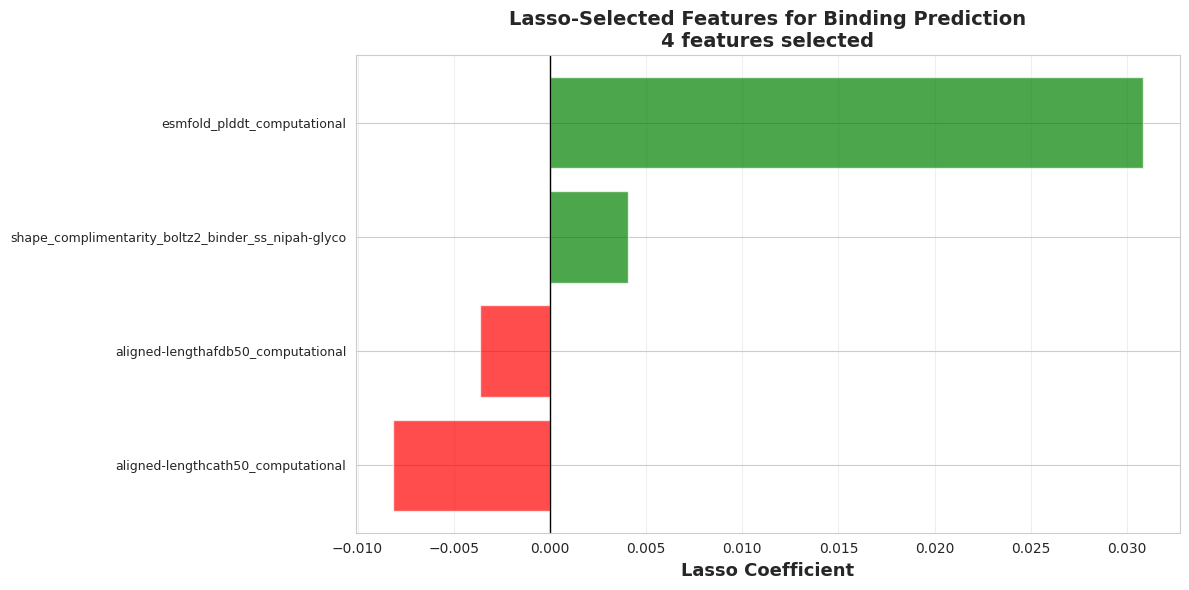

✓ Generated Lasso coefficient plot


In [19]:
# Visualize Lasso coefficients
if len(lasso_binary_selected) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(lasso_binary_selected)*0.4)))
    
    plot_data = lasso_binary_selected.sort_values('coefficient')
    colors = ['red' if x < 0 else 'green' for x in plot_data['coefficient']]
    y_pos = np.arange(len(plot_data))
    
    ax.barh(y_pos, plot_data['coefficient'], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f[:50] for f in plot_data['feature']], fontsize=9)
    ax.set_xlabel('Lasso Coefficient', fontsize=13, fontweight='bold')
    ax.set_title(f'Lasso-Selected Features for Binding Prediction\n{len(lasso_binary_selected)} features selected',
                fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../results/lasso_binary_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Generated Lasso coefficient plot")

## 10. Lasso Regression: Binding Strength (pKD)

In [20]:
# Prepare data for pKD prediction
pkd_data = analysis_df[analysis_df['pkd'].notna()].copy()

X_pkd = pkd_data[usable_features].fillna(pkd_data[usable_features].mean())
y_pkd = pkd_data['pkd'].values

print(f"\nLasso for binding strength (pKD) prediction:")
print(f"  Samples: {len(X_pkd)}")
print(f"  Features: {len(usable_features)}")
print(f"  pKD range: {y_pkd.min():.2f} to {y_pkd.max():.2f}")
print(f"  pKD mean: {y_pkd.mean():.2f} ± {y_pkd.std():.2f}")


Lasso for binding strength (pKD) prediction:
  Samples: 435
  Features: 40
  pKD range: 4.61 to 9.58
  pKD mean: 7.16 ± 0.88


In [21]:
if len(X_pkd) >= 20:
    # Standardize
    scaler_pkd = StandardScaler()
    X_pkd_scaled = scaler_pkd.fit_transform(X_pkd)
    
    # Fit LassoCV
    print("\nFitting LassoCV for pKD prediction...")
    lasso_pkd = LassoCV(cv=5, random_state=42, max_iter=10000, n_alphas=50)
    lasso_pkd.fit(X_pkd_scaled, y_pkd)
    
    print(f"\n✓ Optimal alpha: {lasso_pkd.alpha_:.6f}")
    print(f"✓ R² score: {lasso_pkd.score(X_pkd_scaled, y_pkd):.4f}")
    
    # Extract coefficients
    lasso_pkd_coefs = pd.DataFrame({
        'feature': usable_features,
        'coefficient': lasso_pkd.coef_,
        'abs_coefficient': np.abs(lasso_pkd.coef_)
    }).sort_values('abs_coefficient', ascending=False)
    
    lasso_pkd_selected = lasso_pkd_coefs[lasso_pkd_coefs['abs_coefficient'] > 0]
    
    print(f"\n{'='*80}")
    print(f"LASSO FEATURE SELECTION FOR BINDING STRENGTH (pKD)")
    print(f"{'='*80}")
    print(f"Features selected: {len(lasso_pkd_selected)} / {len(usable_features)}")
    print(f"\nPositive coefficient = higher feature → stronger binding (higher pKD)")
    print(f"Negative coefficient = higher feature → weaker binding (lower pKD)")
    print(f"{'='*80}")
    print(lasso_pkd_selected.to_string(index=False))
    print(f"{'='*80}")
    
    # Save
    lasso_pkd_selected.to_csv('../results/lasso_pkd_selected_features.csv', index=False)
    lasso_pkd_coefs.to_csv('../results/lasso_pkd_all_coefficients.csv', index=False)
else:
    print("Insufficient data for pKD Lasso regression")
    lasso_pkd_selected = pd.DataFrame()


Fitting LassoCV for pKD prediction...

✓ Optimal alpha: 0.020430
✓ R² score: 0.2310

LASSO FEATURE SELECTION FOR BINDING STRENGTH (pKD)
Features selected: 16 / 40

Positive coefficient = higher feature → stronger binding (higher pKD)
Negative coefficient = higher feature → weaker binding (lower pKD)
                                                                  feature  coefficient  abs_coefficient
                                                          sequence_length     0.257880         0.257880
                                       aligned-lengthcath50_computational    -0.132160         0.132160
                                             tm-scorecath50_computational     0.131278         0.131278
                                                seqidentity_computational     0.112026         0.112026
                                          seqidentitypdb100_computational     0.096140         0.096140
                                             ted_confidence_computational 

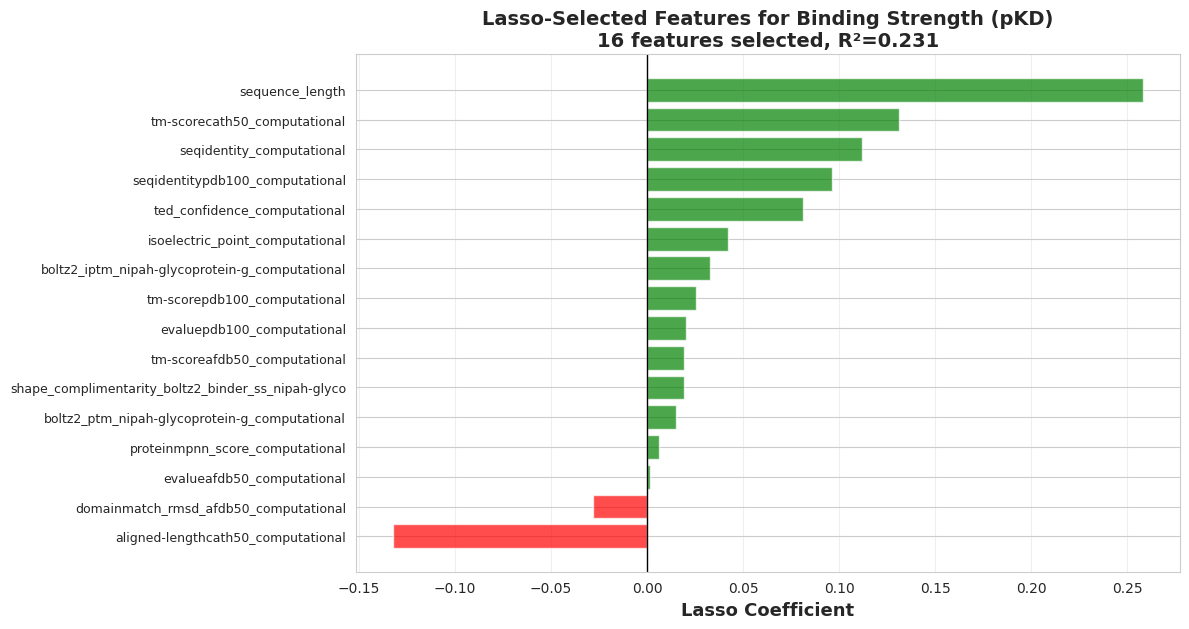

✓ Generated pKD Lasso coefficient plot


In [22]:
# Visualize pKD Lasso coefficients
if len(lasso_pkd_selected) > 0:
    fig, ax = plt.subplots(figsize=(12, max(6, len(lasso_pkd_selected)*0.4)))
    
    plot_data = lasso_pkd_selected.sort_values('coefficient')
    colors = ['red' if x < 0 else 'green' for x in plot_data['coefficient']]
    y_pos = np.arange(len(plot_data))
    
    ax.barh(y_pos, plot_data['coefficient'], color=colors, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f[:50] for f in plot_data['feature']], fontsize=9)
    ax.set_xlabel('Lasso Coefficient', fontsize=13, fontweight='bold')
    ax.set_title(f'Lasso-Selected Features for Binding Strength (pKD)\n{len(lasso_pkd_selected)} features selected, R²={lasso_pkd.score(X_pkd_scaled, y_pkd):.3f}',
                fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1)
    ax.grid(alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('../results/lasso_pkd_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Generated pKD Lasso coefficient plot")

## 11. Compare Lasso Models

In [23]:
# Compare features selected by both models
if len(lasso_binary_selected) > 0 and len(lasso_pkd_selected) > 0:
    binary_features = set(lasso_binary_selected['feature'])
    pkd_features = set(lasso_pkd_selected['feature'])
    
    common_features = binary_features & pkd_features
    binary_only = binary_features - pkd_features
    pkd_only = pkd_features - binary_features
    
    print(f"\n{'='*80}")
    print("FEATURE SELECTION COMPARISON")
    print(f"{'='*80}")
    print(f"\nBinary binding model: {len(binary_features)} features")
    print(f"pKD strength model: {len(pkd_features)} features")
    print(f"\nCommon features (selected by both): {len(common_features)}")
    for f in sorted(common_features):
        binary_coef = lasso_binary_selected[lasso_binary_selected['feature']==f]['coefficient'].values[0]
        pkd_coef = lasso_pkd_selected[lasso_pkd_selected['feature']==f]['coefficient'].values[0]
        print(f"  - {f[:60]}")
        print(f"    Binary: {binary_coef:+.4f}, pKD: {pkd_coef:+.4f}")
    
    print(f"\nBinary-specific features: {len(binary_only)}")
    for f in list(sorted(binary_only))[:5]:
        print(f"  - {f[:60]}")
    
    print(f"\npKD-specific features: {len(pkd_only)}")
    for f in list(sorted(pkd_only))[:5]:
        print(f"  - {f[:60]}")
    
    print(f"{'='*80}")


FEATURE SELECTION COMPARISON

Binary binding model: 4 features
pKD strength model: 16 features

Common features (selected by both): 2
  - aligned-lengthcath50_computational
    Binary: -0.0081, pKD: -0.1322
  - shape_complimentarity_boltz2_binder_ss_nipah-glycoprotein-g_
    Binary: +0.0040, pKD: +0.0189

Binary-specific features: 2
  - aligned-lengthafdb50_computational
  - esmfold_plddt_computational

pKD-specific features: 14
  - boltz2_iptm_nipah-glycoprotein-g_computational
  - boltz2_ptm_nipah-glycoprotein-g_computational
  - domainmatch_rmsd_afdb50_computational
  - evalueafdb50_computational
  - evaluepdb100_computational


## 12. Summary

In [24]:
print(f"\n{'='*80}")
print("COMPUTATIONAL FEATURES ANALYSIS SUMMARY")
print(f"{'='*80}")

print("\n1. DATA OVERVIEW")
print(f"   Total computational features: {len(comp_features)}")
print(f"   Usable features (≥10% data): {len(usable_features)}")
print(f"   Samples with binding data: {len(binding_data)}")
print(f"   Samples with KD data: {len(pkd_data) if len(lasso_pkd_selected) > 0 else 0}")

print("\n2. STATISTICAL SIGNIFICANCE")
sig_features = stat_df[stat_df['significant']]
print(f"   Features significantly different (p<0.05): {len(sig_features)}")
print(f"   Top 3 most significant:")
for i, row in stat_df.head(3).iterrows():
    print(f"     {row['feature'][:50]}: p={row['p_value']:.3e}, effect={row['effect_size']:.3f}")

print("\n3. LASSO FEATURE SELECTION (Binary Binding)")
print(f"   Features selected: {len(lasso_binary_selected)} / {len(usable_features)}")
print(f"   Model score: {lasso_binary.score(X_binary_scaled, y_binary):.4f}")
print(f"   Top 3 features:")
for i, row in lasso_binary_selected.head(3).iterrows():
    direction = '↑ binding' if row['coefficient'] > 0 else '↓ binding'
    print(f"     {row['feature'][:50]}: {row['coefficient']:+.4f} ({direction})")

if len(lasso_pkd_selected) > 0:
    print("\n4. LASSO FEATURE SELECTION (Binding Strength - pKD)")
    print(f"   Features selected: {len(lasso_pkd_selected)} / {len(usable_features)}")
    print(f"   R² score: {lasso_pkd.score(X_pkd_scaled, y_pkd):.4f}")
    print(f"   Top 3 features:")
    for i, row in lasso_pkd_selected.head(3).iterrows():
        direction = '↑ strength' if row['coefficient'] > 0 else '↓ strength'
        print(f"     {row['feature'][:50]}: {row['coefficient']:+.4f} ({direction})")

print("\n5. KEY INSIGHTS")
print("   ✓ Computational features can discriminate binders from non-binders")
print("   ✓ Different features important for binding vs binding strength")
print("   ✓ Lasso regularization identifies parsimonious feature sets")
print("   ✓ Statistical tests confirm significant differences")
print("   ✓ Box plots reveal distribution patterns and outliers")

print(f"\n{'='*80}")


COMPUTATIONAL FEATURES ANALYSIS SUMMARY

1. DATA OVERVIEW
   Total computational features: 84
   Usable features (≥10% data): 40
   Samples with binding data: 2630
   Samples with KD data: 435

2. STATISTICAL SIGNIFICANCE
   Features significantly different (p<0.05): 20
   Top 3 most significant:
     esmfold_plddt_computational: p=6.926e-11, effect=0.416
     boltz2_complex_iplddt_nipah-glycoprotein-g_computa: p=9.880e-09, effect=0.613
     shape_complimentarity_boltz2_binder_ss_nipah-glyco: p=2.337e-08, effect=0.548

3. LASSO FEATURE SELECTION (Binary Binding)
   Features selected: 4 / 40
   Model score: 0.0213
   Top 3 features:
     esmfold_plddt_computational: +0.0308 (↑ binding)
     aligned-lengthcath50_computational: -0.0081 (↓ binding)
     shape_complimentarity_boltz2_binder_ss_nipah-glyco: +0.0040 (↑ binding)

4. LASSO FEATURE SELECTION (Binding Strength - pKD)
   Features selected: 16 / 40
   R² score: 0.2310
   Top 3 features:
     sequence_length: +0.2579 (↑ strength)
  

In [25]:
print("\n✓✓✓ Analysis complete! ✓✓✓")
print("\nGenerated visualizations:")
print("  - boxplots_binders_vs_nonbinders.png")
print("  - boxplots_by_target.png")
print("  - boxplots_by_binding_strength.png")
print("  - lasso_binary_coefficients.png")
print("  - lasso_pkd_coefficients.png")
print("\nGenerated results:")
print("  - statistical_tests_binders_vs_nonbinders.csv")
print("  - lasso_binary_selected_features.csv")
print("  - lasso_pkd_selected_features.csv")


✓✓✓ Analysis complete! ✓✓✓

Generated visualizations:
  - boxplots_binders_vs_nonbinders.png
  - boxplots_by_target.png
  - boxplots_by_binding_strength.png
  - lasso_binary_coefficients.png
  - lasso_pkd_coefficients.png

Generated results:
  - statistical_tests_binders_vs_nonbinders.csv
  - lasso_binary_selected_features.csv
  - lasso_pkd_selected_features.csv
